# supervisor vs. routing
- supervisor: 비용 ↑
- routing: 범용

# 1. API 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

# 2. 라우팅 스키마 정의
-  `with_structed_output`으로 라우팅 결정을 구조화

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

class Route(BaseModel):
    # 시, 글, 농담
    step: Literal["poem", "story", "joke"] = Field(description="다음 라우팅 단계 선택")

llm = ChatOpenAI(model = "gpt-4o-mini", temperature=0)
router = llm.with_structured_output(Route) # `with_structed_output`으로 라우팅 결정을 구조화

- test

In [8]:
message = {"role": "system", "content": "너는 시를 쓰는 작가야. 시 한편을 작성해줘"}
result = router.invoke([message])
print(result)

step='poem'


In [9]:
message = {"role": "system", "content": "너는 문학작품을 쓰는 작가야. 문학을 작성해줘"}
result = router.invoke([message])
print(result)

step='story'


In [7]:
message = {"role": "system", "content": "너는 농담 전문가로 농담을 만들어줘"}
result = router.invoke([message])
print(result)

step='joke'


# 3. State 정의

In [10]:
from typing import TypedDict

class State(TypedDict):
    input: str # 사용자 입력
    decision: str # 라우팅 결정
    output: str # 최종 출력

# 4. 노드 함수 정의

- router

In [11]:
def llm_call_router(state: State):
    """Router: 입력을 분석하여 적절한 경로 결정"""
    print(f"\n🔀 Router: 입력 분석 중...")
    
    decision = router.invoke([
        SystemMessage(content="사용자 요청을 story, joke, poem 중 하나로 라우팅하세요."),
        HumanMessage(content=state["input"])
    ])
    
    print(f"   📌 선택된 경로: {decision.step}")
    return {"decision": decision.step}

- poem

In [14]:
def llm_call_poem(state: State):
    """시 작성"""
    print(f"\n📜 Poem Writer: 시 작성 중...")
    result = llm.invoke(f"다음 주제로 아름다운 시를 써줘: {state['input']}")
    return {"output": result.content}

- story

In [15]:
def llm_call_story(state: State):
    """이야기 작성"""
    print(f"\n📖 Story Writer: 이야기 작성 중...")
    result = llm.invoke(f"다음 주제로 짧은 이야기를 써줘: {state['input']}")
    return {"output": result.content}

- joke

In [16]:
def llm_call_joke(state: State):
    """농담 작성"""
    print(f"\n😄 Joke Writer: 농담 작성 중...")
    result = llm.invoke(f"다음 주제로 재미있는 농담을 써줘: {state['input']}")
    return {"output": result.content}

# 4. 조건부 라우팅 함수

In [ ]:
def route_decision(state: State):
    """라우팅 결정에 따라 다음 노드 선택"""
    if state["decision"] == "story": # 이야기
        return "llm_call_story"
    elif state["decision"] == "joke": # 농담
        return "llm_call_joke"
    elif state["decision"] == "poem": # 시
        return "llm_call_poem"
    else:
        return "llm_call_story"  # 기본값 -> # 응용 error 처리

# 5. 그래프 구성

In [18]:
from langgraph.graph import StateGraph, START, END

# 워크플로우 구성
builder = StateGraph(State)

# 노드 추가
builder.add_node("llm_call_router", llm_call_router)
builder.add_node("llm_call_story", llm_call_story)
builder.add_node("llm_call_joke", llm_call_joke)
builder.add_node("llm_call_poem", llm_call_poem)

# 엣지 추가
builder.add_edge(START, "llm_call_router")

# 조건부 엣지: 라우터 결정에 따라 분기
builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_story": "llm_call_story",
        "llm_call_joke": "llm_call_joke",
        "llm_call_poem": "llm_call_poem"
    }
)

# 각 처리 노드에서 END로 연결
builder.add_edge("llm_call_story", END)
builder.add_edge("llm_call_joke", END)
builder.add_edge("llm_call_poem", END)

# 컴파일
router_workflow = builder.compile()

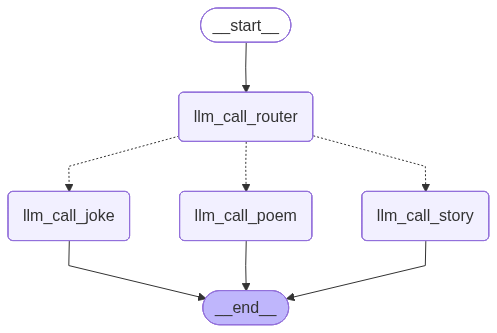

In [19]:
from IPython.display import Image, display
try:
    display(Image(router_workflow.get_graph().draw_mermaid_png()))
except:
    print("그래프: START → router → [story/joke/poem] → END")

# 6. 실행 및 테스트 (스트리밍)

In [20]:
# 다양한 요청 테스트
test_inputs = [
    "고양이에 대한 농담을 해줘",
    "봄에 관한 시를 써줘",
    "용감한 기사 이야기를 들려줘"
]

for user_input in test_inputs:
    print(f"\n{'='*60}")
    print(f"💬 입력: {user_input}")
    
    for chunk in router_workflow.stream({"input": user_input}, stream_mode="updates"):
        for node_name, updates in chunk.items():
            if "output" in updates:
                print(f"\n🤖 결과:\n{updates['output']}...")


💬 입력: 고양이에 대한 농담을 해줘

🔀 Router: 입력 분석 중...
   📌 선택된 경로: joke

😄 Joke Writer: 농담 작성 중...

🤖 결과:
물론이죠! 여기 고양이에 대한 농담 하나 있습니다:

왜 고양이는 컴퓨터를 좋아할까요?

왜냐하면 마우스를 잡는 데는 최고니까요! 😸...

💬 입력: 봄에 관한 시를 써줘

🔀 Router: 입력 분석 중...
   📌 선택된 경로: poem

📜 Poem Writer: 시 작성 중...

🤖 결과:
**봄의 노래**

햇살이 부드럽게 스며드는 아침,  
새싹이 고개를 내미는 순간,  
차가운 겨울의 기억은 사라지고,  
온 세상이 생명으로 가득 차네.

바람은 살랑살랑,  
꽃잎을 춤추게 하고,  
하늘은 푸르른 꿈을 안고,  
구름은 솜사탕처럼 떠다니네.

벚꽃은 하얀 눈처럼 흩날리고,  
노란 유채꽃은 황금빛 물결,  
작은 벌들은 바쁘게 날아,  
봄의 향기를 담아가네.

아이들의 웃음소리,  
연못가의 개구리 노래,  
모든 것이 다시 태어나는 이 순간,  
봄은 우리에게 희망을 속삭여.

이제는 잊었던 사랑의 기억,  
따스한 손길로 다시 피어나,  
봄의 품에 안겨,  
우리는 함께 꿈꾸네....

💬 입력: 용감한 기사 이야기를 들려줘

🔀 Router: 입력 분석 중...
   📌 선택된 경로: story

📖 Story Writer: 이야기 작성 중...

🤖 결과:
옛날 옛적, 한 작은 왕국에 용감한 기사가 살고 있었습니다. 그의 이름은 레오였고, 그는 왕국의 평화를 지키기 위해 항상 준비되어 있었습니다. 레오는 뛰어난 검술과 용기뿐만 아니라, 정의를 사랑하는 마음으로 유명했습니다.

어느 날, 왕국에 무서운 드래곤이 나타났습니다. 드래곤은 마을을 공격하고 사람들을 두려움에 떨게 했습니다. 왕은 레오에게 드래곤을 물리쳐 달라고 명령했습니다. 레오는 주저하지 않고 왕의 명령을 받아들였습니다.

레오는 드래곤의 소굴로 향했습니다. 길고 험한 여정을 거쳐 드래곤의 동굴에 도착